# Reinforcement Learning: Optimasi Distribusi Bantuan Bencana Gempa Indonesia

**Proyek Akhir Mata Kuliah Kecerdasan Buatan** | Teknik Komputer - Universitas Indonesia

| Nama | NPM |
|---|---|
| Dwigina Sitti Zahwa | 2306250724 |
| Aisya Rivelia Azzahra | 2306161864 |
| Audy Natalie Cecilia Rumahorbo | 2306266962 |
| Aliya Rizqiningrum Salamun | 2306161813 |

### **Model:** Deep Q-Network (DQN)
### **Dataset:** Earthquakes in Indonesia (Kaggle - BMKG, 2008-2023)


## 1. Install Dependencies

In [1]:
!pip install gymnasium torch matplotlib pandas numpy -q

## 2. Import Libraries

In [2]:
import random
import math
from collections import deque, namedtuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import os

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.10.0+cu128
CUDA available: True


## 3. Upload Dataset

Upload file `katalog_gempa.csv` dari dataset [Earthquakes in Indonesia (Kaggle)](https://www.kaggle.com/datasets/kekavigi/earthquakes-in-indonesia).


In [3]:
from google.colab import files
uploaded = files.upload()  # upload file katalog_gempa.csv

# Note: Jika sudah ada di Google Drive, uncomment baris dibawah
# from google.colab import drive
# drive.mount("/content/drive")
# !cp "/content/drive/MyDrive/path/ke/katalog_gempa.csv" .

# Verifikasi
if os.path.exists("katalog_gempa.csv"):
    df_check = pd.read_csv("katalog_gempa.csv")
    print(f"Dataset loaded: {len(df_check)} baris, kolom: {list(df_check.columns)}")
else:
    print("ERROR: katalog_gempa.csv tidak ditemukan!")


Saving katalog_gempa.csv to katalog_gempa.csv
Dataset loaded: 92887 baris, kolom: ['tgl', 'ot', 'lat', 'lon', 'depth', 'mag', 'remark', 'strike1', 'dip1', 'rake1', 'strike2', 'dip2', 'rake2']


## 3b. Exploratory Data Analysis (EDA)

Visualisasi distribusi dataset gempa BMKG sebelum dimasukkan ke environment.

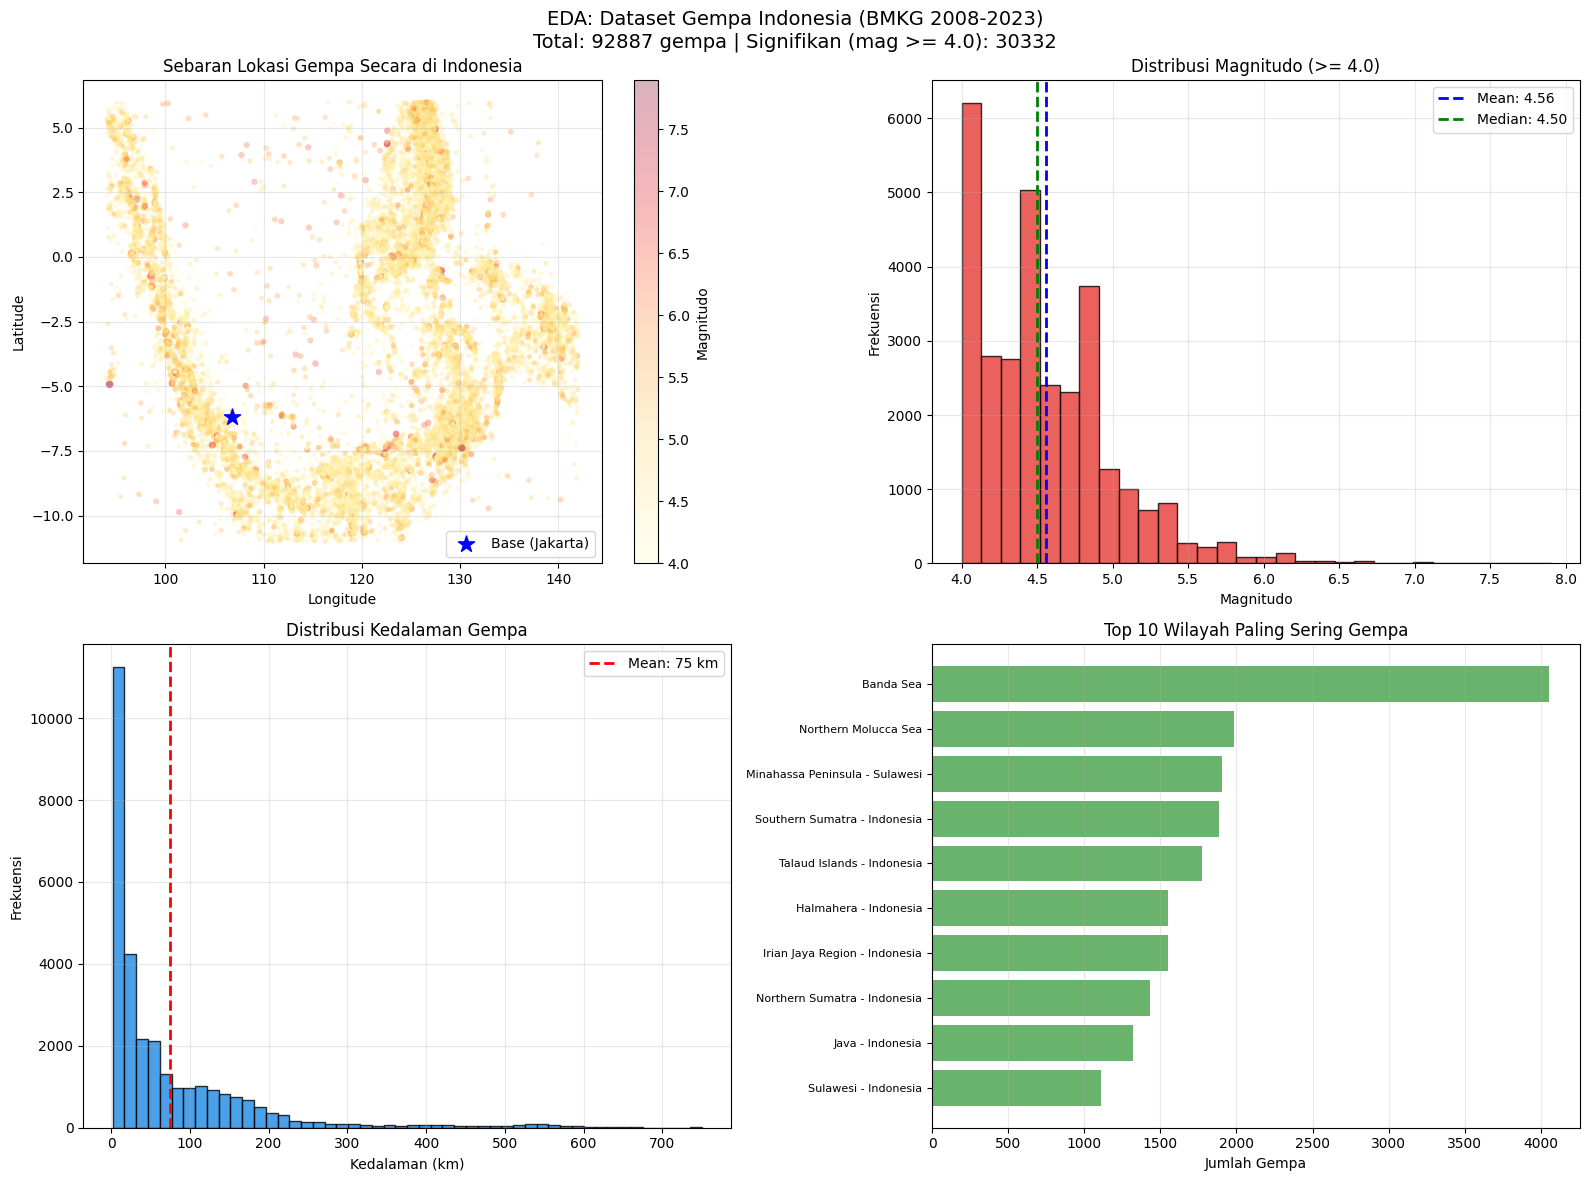


Statistik dataset (mag >= 4.0):
  Jumlah gempa  : 30332
  Magnitudo     : min=4.0, max=7.9, mean=4.56
  Kedalaman     : min=2 km, max=750 km, mean=75 km
  Rentang lat   : -11.00 s/d 6.00
  Rentang lon   : 94.02 s/d 142.00


In [4]:
df_eda = pd.read_csv("katalog_gempa.csv")
df_sig = df_eda[df_eda["mag"] >= 4.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"EDA: Dataset Gempa Indonesia (BMKG 2008-2023)\nTotal: {len(df_eda)} gempa | Signifikan (mag >= 4.0): {len(df_sig)}", fontsize=14)

# Peta sebaran gempa
ax = axes[0, 0]
scatter = ax.scatter(df_sig["lon"], df_sig["lat"], c=df_sig["mag"], cmap="YlOrRd",
                     s=df_sig["mag"]**2 * 0.5, alpha=0.3, edgecolors="none")
ax.scatter(106.8272, -6.1754, s=150, c="blue", marker="*", zorder=5, label="Base (Jakarta)")
plt.colorbar(scatter, ax=ax, label="Magnitudo")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Sebaran Lokasi Gempa Secara di Indonesia")
ax.legend(); ax.grid(True, alpha=0.3)

# Histogram magnitudo
ax = axes[0, 1]
ax.hist(df_sig["mag"], bins=30, color="#E53935", alpha=0.8, edgecolor="black")
ax.axvline(df_sig["mag"].mean(), color="blue", ls="--", lw=2, label=f"Mean: {df_sig['mag'].mean():.2f}")
ax.axvline(df_sig["mag"].median(), color="green", ls="--", lw=2, label=f"Median: {df_sig['mag'].median():.2f}")
ax.set_xlabel("Magnitudo"); ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi Magnitudo (>= 4.0)"); ax.legend(); ax.grid(True, alpha=0.3)

# Histogram kedalaman
ax = axes[1, 0]
ax.hist(df_sig["depth"], bins=50, color="#1E88E5", alpha=0.8, edgecolor="black")
ax.axvline(df_sig["depth"].mean(), color="red", ls="--", lw=2, label=f"Mean: {df_sig['depth'].mean():.0f} km")
ax.set_xlabel("Kedalaman (km)"); ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi Kedalaman Gempa"); ax.legend(); ax.grid(True, alpha=0.3)

# Top 10 wilayah paling sering gempa
ax = axes[1, 1]
top_regions = df_sig["remark"].value_counts().head(10)
bars = ax.barh(range(len(top_regions)), top_regions.values, color="#43A047", alpha=0.8)
ax.set_yticks(range(len(top_regions)))
ax.set_yticklabels(top_regions.index, fontsize=8)
ax.set_xlabel("Jumlah Gempa"); ax.set_title("Top 10 Wilayah Paling Sering Gempa")
ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print(f"\nStatistik dataset (mag >= 4.0):")
print(f"  Jumlah gempa  : {len(df_sig)}")
print(f"  Magnitudo     : min={df_sig['mag'].min():.1f}, max={df_sig['mag'].max():.1f}, mean={df_sig['mag'].mean():.2f}")
print(f"  Kedalaman     : min={df_sig['depth'].min():.0f} km, max={df_sig['depth'].max():.0f} km, mean={df_sig['depth'].mean():.0f} km")
print(f"  Rentang lat   : {df_sig['lat'].min():.2f} s/d {df_sig['lat'].max():.2f}")
print(f"  Rentang lon   : {df_sig['lon'].min():.2f} s/d {df_sig['lon'].max():.2f}")

## 4. Konfigurasi & Hyperparameter

Parameter yang digunakan dalam proyek, `random.seed` untuk **reproduksibilitas**.


In [5]:
# Random Seed
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed()

# Dataset
DATA_PATH = "katalog_gempa.csv"

# Environment
NUM_SITES = 6          # jumlah lokasi bencana per episode
MAX_STEPS = 15         # maksimum langkah per episode
SUPPLY_CAPACITY = 1.0
SUPPLY_PER_SITE = 0.15

# Base camp Jakarta (Kantor BNPB)
BASE_LAT = -6.1754
BASE_LON = 106.8272

# Batas koordinat Indonesia (normalisasi)
LAT_MIN, LAT_MAX = -11.0, 6.0
LON_MIN, LON_MAX = 95.0, 141.0

# Gempa signifikan
MIN_MAGNITUDE = 4.0

# DQN Hyperparameters
LEARNING_RATE = 1e-3 # Adam optimizer
GAMMA = 0.99 # Discount factor
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
BATCH_SIZE = 128
MEMORY_SIZE = 10000
TARGET_UPDATE = 10
NUM_EPISODES = 1000 # Training episodes
HIDDEN_DIM = 128 # MLP architecture

# Reward Weights
REWARD_SERVE = 10.0 # Magnitude multiplier
REWARD_DISTANCE_PENALTY = -0.5
REWARD_INVALID_ACTION = -5.0
REWARD_COMPLETION_BONUS = 20.0
REWARD_STEP_PENALTY = -0.1

print("Konfigurasi loaded")
print(f"NUM_SITES={NUM_SITES}, NUM_EPISODES={NUM_EPISODES}, SEED={SEED}")


Konfigurasi loaded
NUM_SITES=6, NUM_EPISODES=1000, SEED=42


## 5. Custom Environment

Environment RL untuk optimasi distribusi bantuan bencana gempa.

- **State**: membaca posisi agent, sisa supply, info tiap site (`lat, lon, mag, depth, served`)
- **Action**: pilih 1 dari 6 lokasi bencana untuk dikunjungi
- **Reward**: +magnitudo saat melayani (agar proporsional), -penalty jarak (agar rute efisien), +bonus jika semua berjalan


In [6]:
def haversine(lat1, lon1, lat2, lon2):
    """Hitung jarak (km) antara dua koordinat"""
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) ** 2)
    return R * 2 * math.asin(math.sqrt(a))


def normalize_lat(lat):
    return (lat - LAT_MIN) / (LAT_MAX - LAT_MIN)

def normalize_lon(lon):
    return (lon - LON_MIN) / (LON_MAX - LON_MIN)

def normalize_mag(mag):
    return mag / 9.0

def normalize_depth(depth):
    return min(depth / 700.0, 1.0)


class DisasterReliefEnv(gym.Env):
    """Environment RL: agent memutuskan urutan pengiriman bantuan ke lokasi gempa"""

    metadata = {"render_modes": ["human"]}

    def __init__(self, data_path=DATA_PATH, num_sites=NUM_SITES,
                 max_steps=MAX_STEPS, seed=SEED):
        super().__init__()
        self.df = pd.read_csv(data_path)
        self.df = self.df[self.df["mag"] >= MIN_MAGNITUDE].reset_index(drop=True)
        self.num_sites = num_sites
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Discrete(num_sites)
        state_dim = 3 + num_sites * 5
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(state_dim,), dtype=np.float32
        )
        self.reset()

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        indices = self.rng.choice(len(self.df), size=self.num_sites, replace=False)
        self.sites = self.df.iloc[indices][["lat", "lon", "mag", "depth", "remark"]].copy()
        self.sites = self.sites.reset_index(drop=True)

        self.agent_lat = BASE_LAT
        self.agent_lon = BASE_LON
        self.supply = SUPPLY_CAPACITY
        self.served = np.zeros(self.num_sites, dtype=bool)
        self.current_step = 0
        self.total_distance = 0.0
        self.visit_order = []
        return self._get_state(), {}

    def _get_state(self):
        state = [normalize_lat(self.agent_lat), normalize_lon(self.agent_lon), self.supply]
        for i in range(self.num_sites):
            s = self.sites.iloc[i]
            state.extend([
                normalize_lat(s["lat"]), normalize_lon(s["lon"]),
                normalize_mag(s["mag"]), normalize_depth(s["depth"]),
                1.0 if self.served[i] else 0.0,
            ])
        return np.array(state, dtype=np.float32)

    def step(self, action):
        self.current_step += 1
        reward = REWARD_STEP_PENALTY

        if self.served[action]:
            reward += REWARD_INVALID_ACTION
            truncated = self.current_step >= self.max_steps
            return self._get_state(), reward, False, truncated, {"invalid": True}

        site = self.sites.iloc[action]
        distance = haversine(self.agent_lat, self.agent_lon, site["lat"], site["lon"])
        self.total_distance += distance
        self.agent_lat = site["lat"]
        self.agent_lon = site["lon"]
        self.supply -= SUPPLY_PER_SITE
        self.served[action] = True
        self.visit_order.append(action)

        depth_factor = max(0.5, 1.0 - site["depth"] / 700.0)
        mag_reward = site["mag"] * REWARD_SERVE * depth_factor
        dist_penalty = (distance / 100.0) * REWARD_DISTANCE_PENALTY
        reward += mag_reward + dist_penalty

        if np.all(self.served):
            reward += REWARD_COMPLETION_BONUS

        terminated = np.all(self.served) or self.supply <= 0
        truncated = self.current_step >= self.max_steps

        info = {
            "invalid": False, "distance": distance,
            "total_distance": self.total_distance,
            "sites_served": int(np.sum(self.served)),
            "site_name": site["remark"], "site_mag": site["mag"],
        }
        return self._get_state(), reward, terminated, truncated, info

    def get_valid_actions(self):
        return [i for i in range(self.num_sites) if not self.served[i]]

    def render(self):
        served = int(np.sum(self.served))
        print(f"Step {self.current_step} | Served: {served}/{self.num_sites} | "
              f"Supply: {self.supply:.2f} | Distance: {self.total_distance:.0f} km")
        for i in range(self.num_sites):
            s = self.sites.iloc[i]
            tag = "DONE" if self.served[i] else "    "
            print(f"  [{tag}] Site {i}: {s['remark']} (M{s['mag']:.1f}, depth {s['depth']:.0f}km)")

# Test environment
env_test = DisasterReliefEnv()
state_test, _ = env_test.reset(seed=42)
print(f"State dim: {len(state_test)}")
print(f"Action space: {env_test.action_space}")
print(f"Dataset: {len(env_test.df)} gempa (mag >= {MIN_MAGNITUDE})")
print(f"Sites per episode: {NUM_SITES}")
env_test.render()


State dim: 33
Action space: Discrete(6)
Dataset: 30332 gempa (mag >= 4.0)
Sites per episode: 6
Step 0 | Served: 0/6 | Supply: 1.00 | Distance: 0 km
  [    ] Site 0: Halmahera - Indonesia (M4.0, depth 112km)
  [    ] Site 1: Sulawesi - Indonesia (M4.2, depth 10km)
  [    ] Site 2: Sulawesi - Indonesia (M4.2, depth 31km)
  [    ] Site 3: Banda Sea (M4.8, depth 106km)
  [    ] Site 4: Minahassa Peninsula - Sulawesi (M5.4, depth 79km)
  [    ] Site 5: Southern Molucca Sea (M4.7, depth 10km)


## 6. DQN Agent

Implementasi Deep Q-Network dengan:
- **Replay Buffer**: menyimpan log (`s, a, r, s', done`) untuk training
- **Target Network**: stabilisasi training dengan network terpisah yang di-*update* berkala agar target Q-value stabil
- **Epsilon-Greedy**: eksplorasi vs eksploitasi untuk *balancing* antara coba rute baru atau terbaik yang sudah dipelajari


In [7]:
Transition = namedtuple("Transition",
                        ("state", "action", "reward", "next_state", "done"))


class ReplayBuffer:
    """transisi disimpan untuk experience replay."""

    def __init__(self, capacity=MEMORY_SIZE):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*batch))
        states = torch.FloatTensor(np.array(batch.state))
        actions = torch.LongTensor(batch.action).unsqueeze(1)
        rewards = torch.FloatTensor(batch.reward).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(batch.next_state))
        dones = torch.FloatTensor(batch.done).unsqueeze(1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """MLP: Q(state) -> q_value per action."""

    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    """Deep Q-Network agent dengan epsilon-greedy."""

    def __init__(self, state_dim, action_dim, seed=SEED):
        set_seed(seed)
        self.action_dim = action_dim
        self.policy_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LEARNING_RATE)
        self.memory = ReplayBuffer()
        self.epsilon = EPSILON_START
        self.name = "DQN"

    def select_action(self, state, valid_actions=None, env=None):
        # env hanya dipakai baseline heuristic
        if random.random() < self.epsilon:
            if valid_actions:
                return random.choice(valid_actions)
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            q = self.policy_net(torch.FloatTensor(state).unsqueeze(0)).squeeze()
            if valid_actions:
                mask = torch.full((self.action_dim,), float("-inf"))
                for a in valid_actions:
                    mask[a] = 0.0
                q = q + mask
            return q.argmax().item()

    def learn(self):
        if len(self.memory) < BATCH_SIZE:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(BATCH_SIZE)
        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            target = rewards + GAMMA * next_q * (1 - dones)
        loss = nn.MSELoss()(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)

    def save(self, path="model_dqn.pth"):
        torch.save({
            "policy_net": self.policy_net.state_dict(),
            "target_net": self.target_net.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "epsilon": self.epsilon,
        }, path)

    def load(self, path="model_dqn.pth"):
        ckpt = torch.load(path, weights_only=True)
        self.policy_net.load_state_dict(ckpt["policy_net"])
        self.target_net.load_state_dict(ckpt["target_net"])
        self.optimizer.load_state_dict(ckpt["optimizer"])
        self.epsilon = ckpt["epsilon"]

print("DQN Agent ready.")
print(f"  State dim: {3 + NUM_SITES * 5}, Action dim: {NUM_SITES}")
print(f"  Hidden dim: {HIDDEN_DIM}, LR: {LEARNING_RATE}")

DQN Agent ready.
  State dim: 33, Action dim: 6
  Hidden dim: 128, LR: 0.001


## 7. Fungsi Training

Training loop: loop utama untuk training agent yang berinteraksi dengan environment, menyimpan pengalaman, dan belajar dari replay buffer. Set untuk print metrik per 100 episode untuk memantau progres.


In [8]:
def train(num_episodes=NUM_EPISODES, verbose=True):
    set_seed(SEED)
    env = DisasterReliefEnv()
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    agent = DQNAgent(state_dim, action_dim)

    rewards_history = []
    loss_history = []
    epsilon_history = []
    sites_served_history = []
    distance_history = []

    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        total_reward = 0.0
        ep_losses = []

        while True:
            valid = env.get_valid_actions()
            action = agent.select_action(state, valid)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, float(done))
            loss = agent.learn()
            if loss is not None:
                ep_losses.append(loss)

            total_reward += reward
            state = next_state
            if done:
                break

        agent.decay_epsilon()
        if ep % TARGET_UPDATE == 0:
            agent.update_target()

        rewards_history.append(total_reward)
        loss_history.append(np.mean(ep_losses) if ep_losses else 0.0)
        epsilon_history.append(agent.epsilon)
        sites_served_history.append(int(np.sum(env.served)))
        distance_history.append(env.total_distance)

        if verbose and (ep + 1) % 100 == 0:
            avg_r = np.mean(rewards_history[-100:])
            avg_s = np.mean(sites_served_history[-100:])
            print(f"Episode {ep+1}/{num_episodes} | "
                  f"Avg Reward: {avg_r:.2f} | "
                  f"Avg Served: {avg_s:.1f}/{NUM_SITES} | "
                  f"Eps: {agent.epsilon:.3f}")

    agent.save("model_dqn.pth")
    if verbose:
        print("Model saved: model_dqn.pth")

    metrics = {
        "rewards": rewards_history,
        "losses": loss_history,
        "epsilons": epsilon_history,
        "sites_served": sites_served_history,
        "distances": distance_history,
    }
    return agent, env, metrics

print("Fungsi train() ready.")


Fungsi train() ready.


## 8. Baseline Agents (Bonus: Evaluasi Komparatif)

Tiga baseline untuk perbandingan:
1. **Random**: pilih lokasi secara acak
2. **Greedy-Nearest**: selalu cari titik terdekat
3. **Greedy-Magnitude**: fokus ke gempa terbesar, tidak peduli jarak


In [9]:
class RandomAgent:
    def __init__(self, seed=SEED):
        self.rng = np.random.default_rng(seed)
        self.name = "Random"

    def select_action(self, state, valid_actions=None, env=None):
        if valid_actions:
            return self.rng.choice(valid_actions)
        return self.rng.integers(0, NUM_SITES)


class GreedyNearestAgent:
    def __init__(self):
        self.name = "Greedy-Nearest"

    def select_action(self, state, valid_actions=None, env=None):
        if not valid_actions or env is None:
            return 0
        best, min_d = valid_actions[0], float("inf")
        for a in valid_actions:
            s = env.sites.iloc[a]
            d = ((env.agent_lat - s["lat"]) ** 2 +
                 (env.agent_lon - s["lon"]) ** 2) ** 0.5
            if d < min_d:
                min_d, best = d, a
        return best


class GreedyMagnitudeAgent:
    def __init__(self):
        self.name = "Greedy-Magnitude"

    def select_action(self, state, valid_actions=None, env=None):
        if not valid_actions or env is None:
            return 0
        best, max_m = valid_actions[0], -1.0
        for a in valid_actions:
            m = env.sites.iloc[a]["mag"]
            if m > max_m:
                max_m, best = m, a
        return best


def evaluate_agent(agent, num_eval=200, seed=SEED):
    env = DisasterReliefEnv(seed=seed)
    rewards, served_list, dist_list = [], [], []

    for ep in range(num_eval):
        state, _ = env.reset(seed=seed + ep + 10000)
        total_reward = 0.0
        while True:
            valid = env.get_valid_actions()
            action = agent.select_action(state, valid, env=env)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        rewards.append(total_reward)
        served_list.append(int(np.sum(env.served)))
        dist_list.append(env.total_distance)

    return {
        "agent_name": agent.name,
        "avg_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "avg_served": np.mean(served_list),
        "avg_distance": np.mean(dist_list),
        "rewards": rewards,
    }

print("Baseline agents ready: Random, Greedy-Nearest, Greedy-Magnitude")


Baseline agents ready: Random, Greedy-Nearest, Greedy-Magnitude


## 9. Fungsi Visualisasi

Fungsi plotting untuk memvisualisasikan hasil training.

In [10]:
def plot_training_curves(metrics):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training Progress DQN Disaster Relief Agent", fontsize=14)
    window = 50

    ax = axes[0, 0]
    r = metrics["rewards"]
    ax.plot(r, alpha=0.3, color="blue", label="Per Episode")
    if len(r) >= window:
        ma = np.convolve(r, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(r)), ma, color="red", lw=2, label=f"Moving Avg ({window})")
    ax.set_xlabel("Episode"); ax.set_ylabel("Total Reward")
    ax.set_title("Reward per Episode"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    lo = metrics["losses"]
    ax.plot(lo, alpha=0.3, color="orange")
    if len(lo) >= window:
        ma = np.convolve(lo, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(lo)), ma, color="red", lw=2)
    ax.set_xlabel("Episode"); ax.set_ylabel("Loss")
    ax.set_title("Training Loss"); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    sv = metrics["sites_served"]
    ax.plot(sv, alpha=0.3, color="green")
    if len(sv) >= window:
        ma = np.convolve(sv, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(sv)), ma, color="red", lw=2)
    ax.axhline(y=NUM_SITES, color="black", ls="--", alpha=0.5, label="Target")
    ax.set_xlabel("Episode"); ax.set_ylabel("Sites Served")
    ax.set_title(f"Sites Served (max {NUM_SITES})"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(metrics["epsilons"], color="purple")
    ax.set_xlabel("Episode"); ax.set_ylabel("Epsilon")
    ax.set_title("Exploration Rate (Epsilon Decay)"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_comparison(results):
    agents = list(results.keys())
    colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336"]
    avg_r = [results[a]["avg_reward"] for a in agents]
    std_r = [results[a]["std_reward"] for a in agents]
    avg_s = [results[a]["avg_served"] for a in agents]
    avg_d = [results[a]["avg_distance"] for a in agents]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("DQN vs Baseline Agents", fontsize=14)
    axes[0].bar(agents, avg_r, yerr=std_r, color=colors, capsize=5, alpha=0.8)
    axes[0].set_ylabel("Average Reward"); axes[0].set_title("Average Reward")
    axes[0].grid(True, alpha=0.3, axis="y")
    axes[1].bar(agents, avg_s, color=colors, alpha=0.8)
    axes[1].axhline(y=NUM_SITES, color="black", ls="--", alpha=0.5, label="Max")
    axes[1].set_ylabel("Avg Sites Served"); axes[1].set_title(f"Avg Sites Served (max {NUM_SITES})")
    axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")
    axes[2].bar(agents, avg_d, color=colors, alpha=0.8)
    axes[2].set_ylabel("Avg Distance (km)"); axes[2].set_title("Avg Total Distance")
    axes[2].grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()


def plot_reward_boxplot(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Distribusi Reward & Distance per Agent (200 episodes)", fontsize=14)
    colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336"]
    agents = list(results.keys())
    reward_data = [results[a]["rewards"] for a in agents]

    bp = axes[0].boxplot(reward_data, labels=agents, patch_artist=True, showmeans=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    axes[0].set_ylabel("Total Reward"); axes[0].set_title("Distribusi Reward per Agent")
    axes[0].grid(True, alpha=0.3, axis="y")

    dist_data = []
    for a in agents:
        env_tmp = DisasterReliefEnv(seed=SEED)
        dists = []
        for ep in range(200):
            state, _ = env_tmp.reset(seed=SEED + ep + 10000)
            ag = [ag for ag in [DQNAgent(env_tmp.observation_space.shape[0], env_tmp.action_space.n),
                                RandomAgent(), GreedyNearestAgent(), GreedyMagnitudeAgent()]
                  if ag.name == a][0]
            if a == "DQN":
                ag.load("model_dqn.pth"); ag.epsilon = 0.0
            while True:
                valid = env_tmp.get_valid_actions()
                action = ag.select_action(state, valid, env=env_tmp)
                state, _, terminated, truncated, _ = env_tmp.step(action)
                if terminated or truncated: break
            dists.append(env_tmp.total_distance)
        dist_data.append(dists)

    bp2 = axes[1].boxplot(dist_data, labels=agents, patch_artist=True, showmeans=True)
    for patch, c in zip(bp2["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    axes[1].set_ylabel("Total Distance (km)"); axes[1].set_title("Distribusi Jarak Tempuh per Agent")
    axes[1].grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()


def plot_episode_demo(env):
    fig, ax = plt.subplots(figsize=(12, 8))
    for i in range(env.num_sites):
        s = env.sites.iloc[i]
        size = (s["mag"] ** 2) * 10
        color = "green" if env.served[i] else "red"
        ax.scatter(s["lon"], s["lat"], s=size, c=color, zorder=5, edgecolors="black", lw=1)
        ax.annotate(f"Site {i}\nM{s['mag']:.1f}\n{s['remark']}",
                    (s["lon"], s["lat"]), textcoords="offset points", xytext=(10, 10), fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    ax.scatter(BASE_LON, BASE_LAT, s=200, c="blue", marker="*", zorder=6, label="Base (Jakarta)")
    if env.visit_order:
        lats = [BASE_LAT] + [env.sites.iloc[j]["lat"] for j in env.visit_order]
        lons = [BASE_LON] + [env.sites.iloc[j]["lon"] for j in env.visit_order]
        ax.plot(lons, lats, "b--", alpha=0.5, lw=1.5, label="Route")
        for step, (lo, la) in enumerate(zip(lons[1:], lats[1:])):
            ax.annotate(str(step + 1), (lo, la), fontsize=9, fontweight="bold",
                        color="blue", ha="center", va="bottom", xytext=(0, -15), textcoords="offset points")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Disaster Relief Route | Served: {int(np.sum(env.served))}/{env.num_sites} | Distance: {env.total_distance:.0f} km")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("Semua fungsi visualisasi: plot_training_curves, plot_comparison, plot_reward_boxplot, plot_episode_demo")

Semua fungsi visualisasi: plot_training_curves, plot_comparison, plot_reward_boxplot, plot_episode_demo


## 10. Training

Training DQN agent selama 1000/ 2000 episode.

In [11]:
agent, env, metrics = train(verbose=True)

Episode 100/1000 | Avg Reward: 215.81 | Avg Served: 6.0/6 | Eps: 0.606
Episode 200/1000 | Avg Reward: 215.20 | Avg Served: 6.0/6 | Eps: 0.367
Episode 300/1000 | Avg Reward: 216.90 | Avg Served: 6.0/6 | Eps: 0.222
Episode 400/1000 | Avg Reward: 213.12 | Avg Served: 6.0/6 | Eps: 0.135
Episode 500/1000 | Avg Reward: 211.10 | Avg Served: 6.0/6 | Eps: 0.082
Episode 600/1000 | Avg Reward: 212.84 | Avg Served: 6.0/6 | Eps: 0.049
Episode 700/1000 | Avg Reward: 213.05 | Avg Served: 6.0/6 | Eps: 0.030
Episode 800/1000 | Avg Reward: 214.11 | Avg Served: 6.0/6 | Eps: 0.018
Episode 900/1000 | Avg Reward: 213.98 | Avg Served: 6.0/6 | Eps: 0.011
Episode 1000/1000 | Avg Reward: 216.52 | Avg Served: 6.0/6 | Eps: 0.010
Model saved: model_dqn.pth


## 11. Training Curves


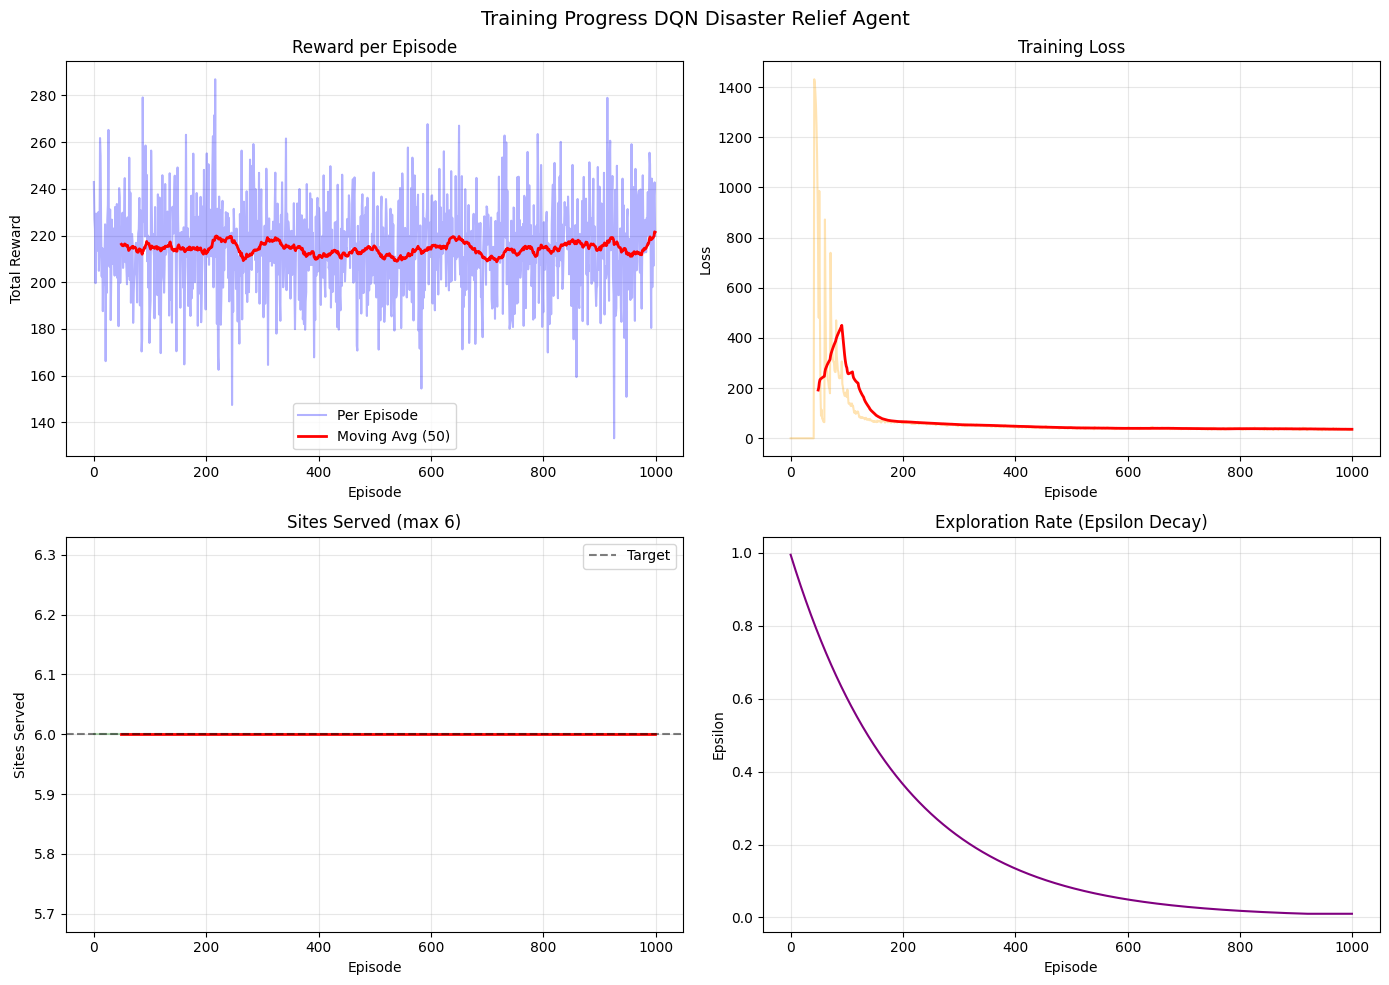

In [27]:
plot_training_curves(metrics)

## 12. Evaluasi Komparatif

Perbandingan DQN agent vs 3 baseline (Random, Greedy-Nearest, Greedy-Magnitude) dengan 200 episode evaluasi masing - masing.

In [28]:
set_seed(SEED)
eval_env = DisasterReliefEnv()
state_dim = eval_env.observation_space.shape[0]
action_dim = eval_env.action_space.n

dqn_eval = DQNAgent(state_dim, action_dim)
dqn_eval.load("model_dqn.pth")
dqn_eval.epsilon = 0.0

agents_to_eval = [dqn_eval, RandomAgent(), GreedyNearestAgent(), GreedyMagnitudeAgent()]

print("=" * 60)
print("EVALUASI KOMPARATIF: DQN vs Baseline Agents")
print("=" * 60)

results = {}
for ag in agents_to_eval:
    r = evaluate_agent(ag)
    results[r["agent_name"]] = r
    print(f"\n{r['agent_name']}:")
    print(f"  Avg Reward      : {r['avg_reward']:.2f} +/- {r['std_reward']:.2f}")
    print(f"  Avg Sites Served: {r['avg_served']:.1f} / {NUM_SITES}")
    print(f"  Avg Distance    : {r['avg_distance']:.0f} km")

print("\n" + "=" * 60)

EVALUASI KOMPARATIF: DQN vs Baseline Agents

DQN:
  Avg Reward      : 213.09 +/- 20.06
  Avg Sites Served: 6.0 / 6
  Avg Distance    : 10030 km

Random:
  Avg Reward      : 213.02 +/- 19.91
  Avg Sites Served: 6.0 / 6
  Avg Distance    : 10044 km

Greedy-Nearest:
  Avg Reward      : 235.04 +/- 16.70
  Avg Sites Served: 6.0 / 6
  Avg Distance    : 5639 km

Greedy-Magnitude:
  Avg Reward      : 211.76 +/- 19.43
  Avg Sites Served: 6.0 / 6
  Avg Distance    : 10296 km



## 13. Grafik Perbandingan


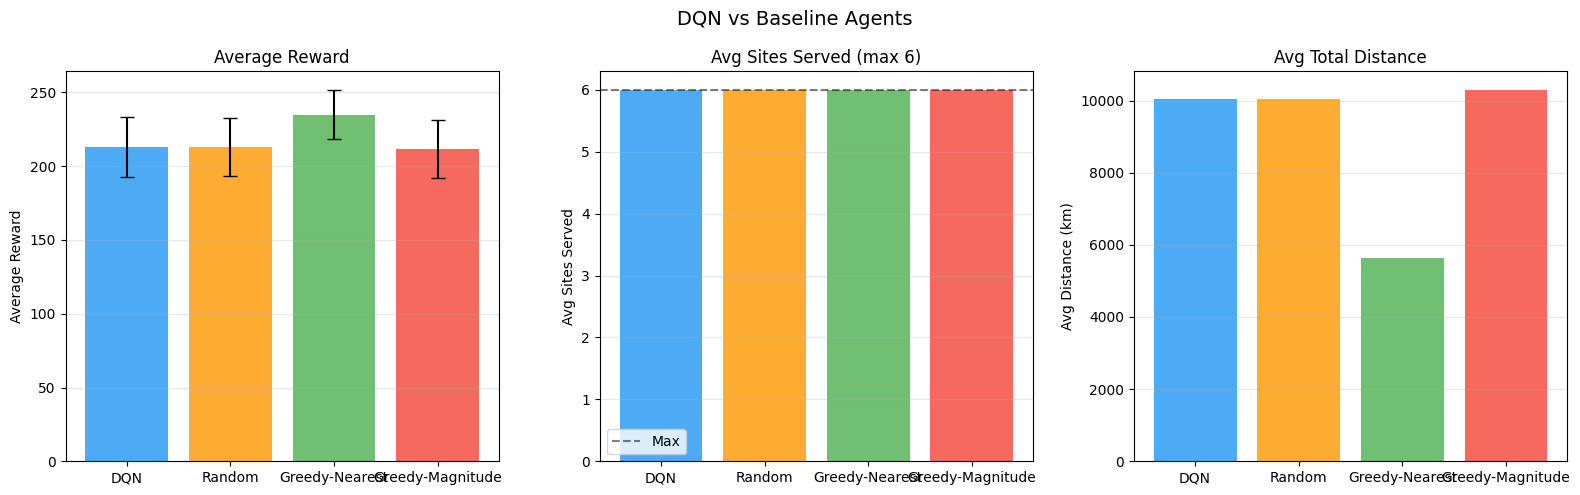

In [29]:
plot_comparison(results)

## 13b. Distribusi Reward & Distance (Box Plot)

Box plot menunjukkan sebaran reward dan jarak tempuh per agent selama 200 episode evaluasi (median, kuartil, dan outlier).

/tmp/ipykernel_1561/1451668210.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(reward_data, labels=agents, patch_artist=True, showmeans=True)
/tmp/ipykernel_1561/1451668210.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(dist_data, labels=agents, patch_artist=True, showmeans=True)


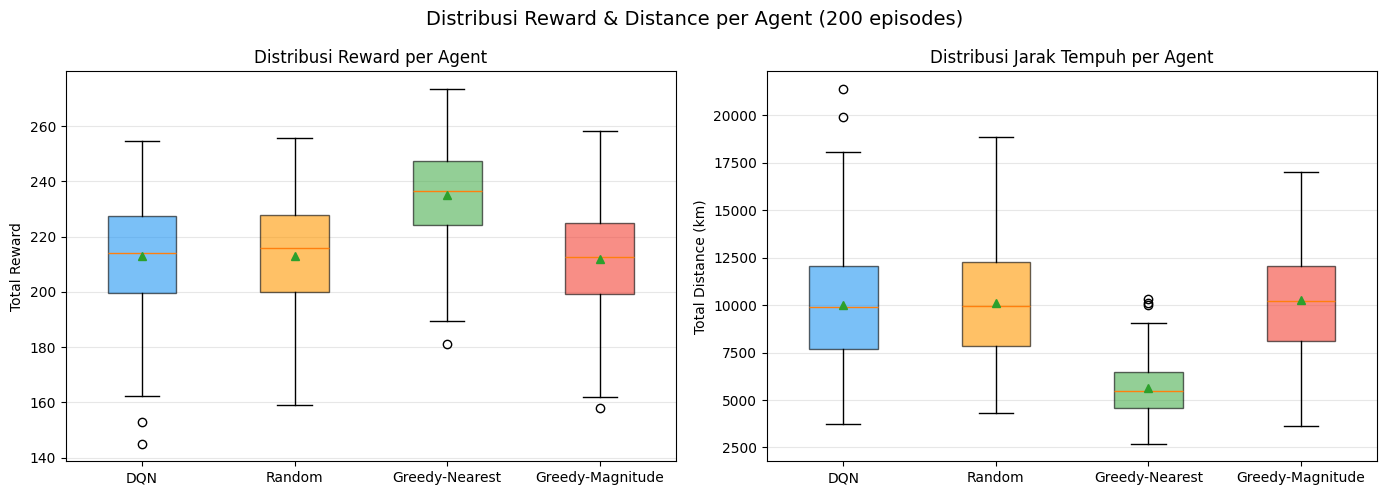

In [30]:
plot_reward_boxplot(results)

## 14. Demo Episode

Visualisasi rute yang dipilih DQN agent pada satu episode contoh.

In [12]:
# 1. Reset environment dengan seed tertentu
set_seed(SEED)
demo_env = DisasterReliefEnv()
state, _ = demo_env.reset(seed=42)

demo_agent = DQNAgent(demo_env.observation_space.shape[0], demo_env.action_space.n)

# 2. Load model_dqn.pth
demo_agent.load("model_dqn.pth")

# 3. Jalankan agent (epsilon=0, pure exploitation)
demo_agent.epsilon = 0.0

# 4. Print rute yang dipilih agent
print("Rute agent terlatih:")
print("-" * 40)
while True:
    valid = demo_env.get_valid_actions()
    action = demo_agent.select_action(state, valid)
    state, reward, terminated, truncated, info = demo_env.step(action)
    if not info.get("invalid"):
        print(f"  -> {info['site_name']} (M{info['site_mag']:.1f}, "
              f"{info['distance']:.0f} km)")
    if terminated or truncated:
        break

print("-" * 40)

# 5. Render state akhir
demo_env.render()

Rute agent terlatih:
----------------------------------------
  -> Sulawesi - Indonesia (M4.2, 1765 km)
  -> Sulawesi - Indonesia (M4.2, 69 km)
  -> Southern Molucca Sea (M4.7, 499 km)
  -> Halmahera - Indonesia (M4.0, 47 km)
  -> Minahassa Peninsula - Sulawesi (M5.4, 656 km)
  -> Banda Sea (M4.8, 1181 km)
----------------------------------------
Step 6 | Served: 6/6 | Supply: 0.10 | Distance: 4218 km
  [DONE] Site 0: Halmahera - Indonesia (M4.0, depth 112km)
  [DONE] Site 1: Sulawesi - Indonesia (M4.2, depth 10km)
  [DONE] Site 2: Sulawesi - Indonesia (M4.2, depth 31km)
  [DONE] Site 3: Banda Sea (M4.8, depth 106km)
  [DONE] Site 4: Minahassa Peninsula - Sulawesi (M5.4, depth 79km)
  [DONE] Site 5: Southern Molucca Sea (M4.7, depth 10km)


## 14b. Analisis Q-Value & Kasus Kegagalan (Error Analysis)

Analisis penyebab kegagalan DQN vs Greedy-Nearest. Identifikasi minimal 3 episode saat DQN memilih rute yang lebih buruk dari Greedy-Nearest & hipotesis penyebabnya.

Menjalankan Error Analysis...
Catatan: Memerlukan model_dqn.pth dari proses training.

ERROR ANALYSIS: DQN vs Greedy-Nearest
Total episode dianalisis: 50
Kasus DQN buruk (gap > 500 km): 50
Kasus DQN lebih baik (gap < -100 km): 0

 Kasus Kegagalan #1 (Episode 26, seed=1067) ---
  DQN distance    : 17662 km
  Greedy distance : 5896 km
  Gap (DQN-Greedy): +11766 km (DQN lebih jauh)
  DQN memilih urutan site: [2, 1, 5, 0, 4, 3]
  Greedy memilih urutan  : [3, 0, 1, 4, 5, 2]
  Sites episode ini:
    Site 0: Northern Sumatra - Indonesia (M4.0, depth 10 km, lon=97.7, lat=1.1)
    Site 1: Northern Sumatra - Indonesia (M4.4, depth 72 km, lon=97.0, lat=2.3)
    Site 2: Halmahera - Indonesia (M4.7, depth 5 km, lon=127.8, lat=1.0)
    Site 3: Java - Indonesia (M4.3, depth 10 km, lon=110.2, lat=-8.9)
    Site 4: Talaud Islands - Indonesia (M4.1, depth 107 km, lon=125.9, lat=2.5)
    Site 5: Northern Molucca Sea (M5.8, depth 58 km, lon=126.5, lat=2.0)
  Hipotesis: DQN memilih site bermagnitudo tinggi

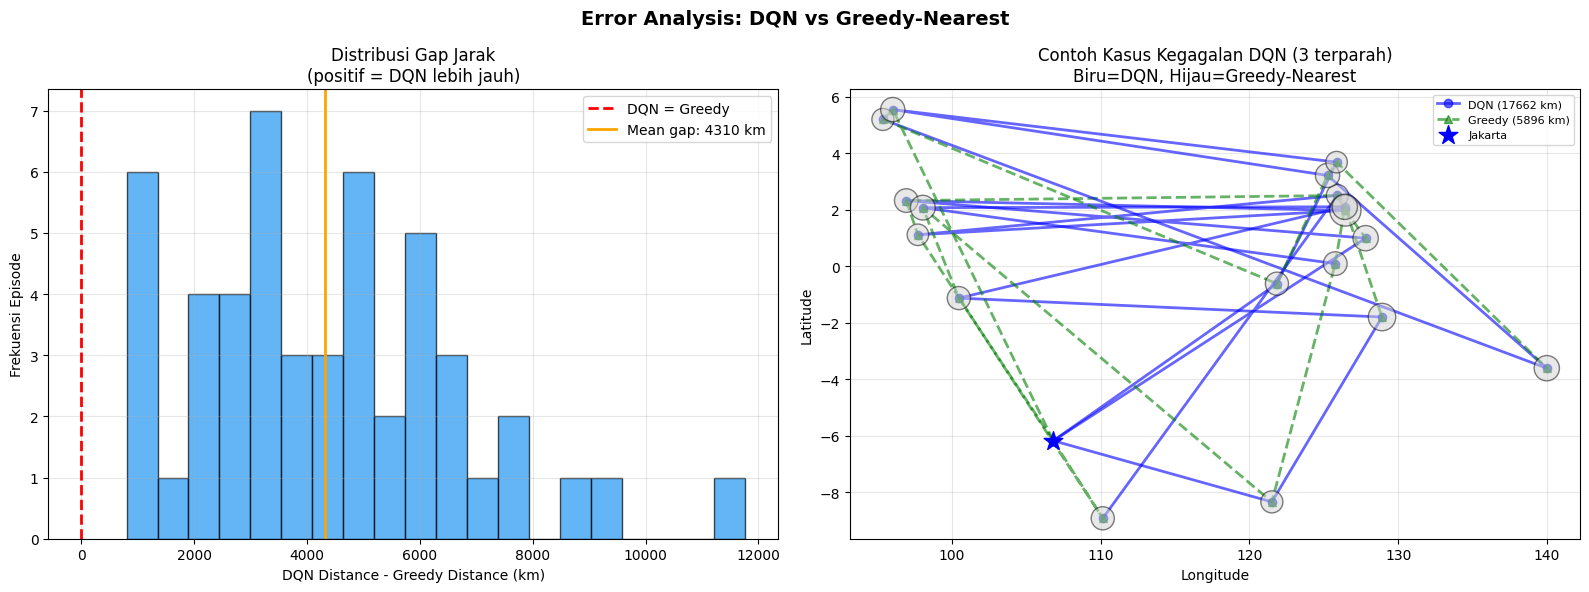

Grafik Error Analysis disimpan: error_analysis.png


In [13]:
def analyze_error_cases(agent, num_cases=50, seed=SEED+999):
    """
    Analisis kasus kegagalan DQN: DQN vs Greedy-Nearest pada episode yang sama.
    Identifikasi 3+ kasus DQN salah.
    """
    greedy_agent = GreedyNearestAgent()
    error_cases = []
    good_cases = []

    for ep in range(num_cases):
        env_a = DisasterReliefEnv()
        env_b = DisasterReliefEnv()
        ep_seed = seed + ep

        # Run DQN
        state_a, _ = env_a.reset(seed=ep_seed)
        agent.epsilon = 0.0
        dqn_actions = []
        while True:
            valid = env_a.get_valid_actions()
            action = agent.select_action(state_a, valid)
            dqn_actions.append(action)
            state_a, _, terminated, truncated, info_a = env_a.step(action)
            if terminated or truncated: break

        # Run Greedy-Nearest pada episode yang sama
        state_b, _ = env_b.reset(seed=ep_seed)
        greedy_actions = []
        while True:
            valid = env_b.get_valid_actions()
            action = greedy_agent.select_action(state_b, valid, env=env_b)
            greedy_actions.append(action)
            state_b, _, terminated, truncated, info_b = env_b.step(action)
            if terminated or truncated: break

        dqn_dist = env_a.total_distance
        greedy_dist = env_b.total_distance
        diff = dqn_dist - greedy_dist

        case_info = {
            "episode": ep,
            "seed": ep_seed,
            "dqn_distance": dqn_dist,
            "greedy_distance": greedy_dist,
            "distance_difference": diff,
            "dqn_actions": dqn_actions,
            "greedy_actions": greedy_actions,
            "sites": env_a.sites.copy(),
        }

        if diff > 500:  # DQN jauh lebih buruk dari Greedy
            error_cases.append(case_info)
        elif diff < -100:  # DQN lebih baik dari Greedy
            good_cases.append(case_info)

    return error_cases, good_cases


def plot_error_analysis(error_cases, good_cases):
    """Visualisasi kegagalan DQN vs Greedy-Nearest."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Error Analysis: DQN vs Greedy-Nearest", fontsize=14, fontweight="bold")

    # Plot 1: Distribusi gap jarak
    all_gaps = [c["distance_difference"] for c in error_cases + good_cases]
    ax = axes[0]
    ax.hist(all_gaps, bins=20, color="#2196F3", alpha=0.7, edgecolor="black")
    ax.axvline(0, color="red", lw=2, ls="--", label="DQN = Greedy")
    ax.axvline(np.mean(all_gaps), color="orange", lw=2, ls="-",
               label=f"Mean gap: {np.mean(all_gaps):.0f} km")
    ax.set_xlabel("DQN Distance - Greedy Distance (km)")
    ax.set_ylabel("Frekuensi Episode")
    ax.set_title("Distribusi Gap Jarak\n(positif = DQN lebih jauh)")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Plot 2: Contoh 3 kasus error terparah
    if len(error_cases) >= 3:
        worst = sorted(error_cases, key=lambda x: x["distance_difference"], reverse=True)[:3]
        for idx, case in enumerate(worst):
            sites = case["sites"]
            ax = axes[1]
            # Plot scatter semua site
            mags = sites["mag"].values
            lons = sites["lon"].values
            lats = sites["lat"].values
            ax.scatter(lons, lats, s=mags**2 * 15, c="lightgray",
                       edgecolors="black", zorder=3, alpha=0.5)

            # Rute DQN
            dqn_lons = [BASE_LON] + [lons[a] for a in case["dqn_actions"][:NUM_SITES]]
            dqn_lats = [BASE_LAT] + [lats[a] for a in case["dqn_actions"][:NUM_SITES]]
            ax.plot(dqn_lons, dqn_lats, "b-o", lw=2, alpha=0.6,
                    label=f"DQN ({case['dqn_distance']:.0f} km)" if idx == 0 else "")

            # Rute Greedy
            g_lons = [BASE_LON] + [lons[a] for a in case["greedy_actions"][:NUM_SITES]]
            g_lats = [BASE_LAT] + [lats[a] for a in case["greedy_actions"][:NUM_SITES]]
            ax.plot(g_lons, g_lats, "g--^", lw=2, alpha=0.6,
                    label=f"Greedy ({case['greedy_distance']:.0f} km)" if idx == 0 else "")

        ax.scatter([BASE_LON], [BASE_LAT], s=200, c="blue", marker="*", zorder=5, label="Jakarta")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.set_title(f"Contoh Kasus Kegagalan DQN (3 terparah)\nBiru=DQN, Hijau=Greedy-Nearest")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "Tidak cukup kasus error\n(< 3 kasus ditemukan)",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=12)

    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafik Error Analysis disimpan: error_analysis.png")


def print_error_cases_report(error_cases, good_cases):
    print("=" * 60)
    print("ERROR ANALYSIS: DQN vs Greedy-Nearest")
    print("=" * 60)
    print(f"Total episode dianalisis: {len(error_cases) + len(good_cases)}")
    print(f"Kasus DQN buruk (gap > 500 km): {len(error_cases)}")
    print(f"Kasus DQN lebih baik (gap < -100 km): {len(good_cases)}")
    print()

    worst = sorted(error_cases, key=lambda x: x["distance_difference"], reverse=True)[:3]
    for i, case in enumerate(worst, 1):
        print(f" Kasus Kegagalan #{i} (Episode {case['episode']}, seed={case['seed']}) ---")
        print(f"  DQN distance    : {case['dqn_distance']:.0f} km")
        print(f"  Greedy distance : {case['greedy_distance']:.0f} km")
        print(f"  Gap (DQN-Greedy): +{case['distance_difference']:.0f} km (DQN lebih jauh)")
        print(f"  DQN memilih urutan site: {case['dqn_actions']}")
        print(f"  Greedy memilih urutan  : {case['greedy_actions']}")
        sites = case["sites"]
        print(f"  Sites episode ini:")
        for j in range(min(NUM_SITES, len(sites))):
            s = sites.iloc[j]
            print(f"    Site {j}: {s['remark']} (M{s['mag']:.1f}, depth {s['depth']:.0f} km, "
                  f"lon={s['lon']:.1f}, lat={s['lat']:.1f})")
        print(f"  Hipotesis: DQN memilih site bermagnitudo tinggi yang jauh dahulu")
        print(f"  Greedy yang memilih site terdekat. Hal ini terjadi karena magnitude reward (~85% total reward) mendominasi distance penalty.")
        print()

    if good_cases:
        best = sorted(good_cases, key=lambda x: x["distance_difference"])[:1]
        print(f"DQN LEBIH BAIK (Episode {best[0]['episode']}) ---")
        print(f"  DQN distance    : {best[0]['dqn_distance']:.0f} km")
        print(f"  Greedy distance : {best[0]['greedy_distance']:.0f} km")
        print(f"  Gap (DQN-Greedy): {best[0]['distance_difference']:.0f} km (DQN lebih dekat)")
        print("  Greedy terjebak pada rute suboptimal karena nearest-first tidak selalu terbaik.")
    print("=" * 60)


# Run Error Analysis
print("Menjalankan Error Analysis...")
print("Catatan: Memerlukan model_dqn.pth dari proses training.")
print()

# Load DQN agent
try:
    err_env = DisasterReliefEnv()
    err_agent = DQNAgent(err_env.observation_space.shape[0], err_env.action_space.n)
    err_agent.load("model_dqn.pth")
    err_agent.epsilon = 0.0

    error_cases, good_cases = analyze_error_cases(err_agent, num_cases=50)
    print_error_cases_report(error_cases, good_cases)
    plot_error_analysis(error_cases, good_cases)
except FileNotFoundError:
    print("model_dqn.pth tidak ditemukan. Jalankan Cell 10 (Training) terlebih dahulu.")


## 15. Peta Rute Agent

Fungsi `plot_episode_demo()` menampilkan peta koordinat Indonesia dengan titik-titik gempa dan rute agent.

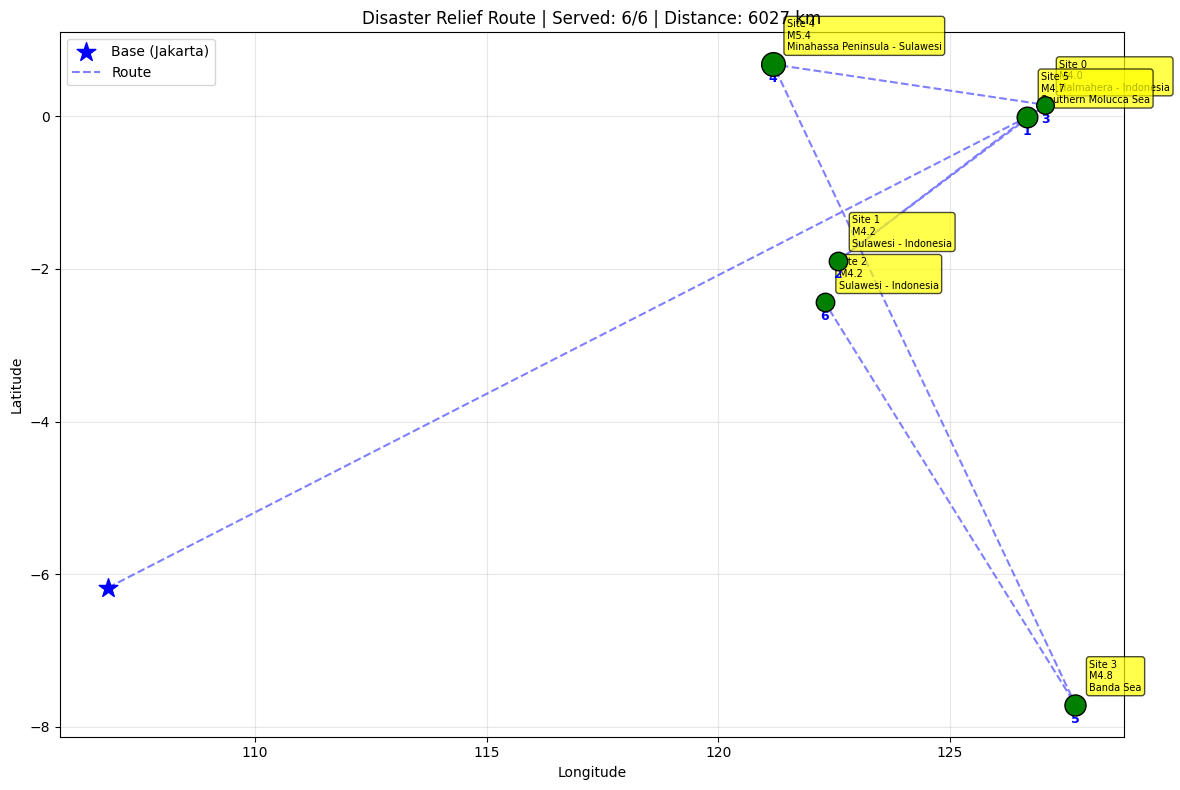

In [19]:
plot_episode_demo(demo_env)

## 16. Analisis Etika & Keterbatasan (Bonus: Analisis Etika, Bias, & Keterbatasan)

### Potensi Bias
1. **Bias magnitudo**: Reward function didominasi komponen magnitudo (~85% total reward), sehingga agent belajar "melayani semua site" tanpa mengoptimasi efisiensi rute. Hal ini menyebabkan DQN performanya sama dengan Random agent dalam jarak tempuh.
2. **Bias geografis**: Base camp di Jakarta membuat lokasi gempa di Indonesia Timur (Papua, Maluku) selalu mendapat penalty jarak lebih besar. Agent cenderung menunda pelayanan ke wilayah timur meskipun magnitudonya lebih besar.
3. **Bias data BMKG**: Dataset hanya mencatat gempa yang terdeteksi oleh jaringan sensor BMKG. Wilayah dengan densitas sensor rendah (pedalaman Papua, Kalimantan) mungkin *under-reported*.

### Edge Cases (Kasus Kegagalan)
1. **Gempa beruntun (aftershock)**: Environment statis, 6 gempa ditentukan di awal episode. Agent tidak bisa merespons gempa susulan yang muncul setelah gempa utama, padahal aftershock sering terjadi dalam hitungan jam.
2. **Supply habis sebelum semuanya**: supply 1.0 dan biaya 0.15 per site, agent hanya bisa melayani maksimal 6 site. Jika `NUM_SITES` menjadi 8+, agent harus belajar memprioritaskan (belum diuji).
3. **Gempa sangat dangkal**: Gempa M4.0 depth 5 km bisa lebih rusak daripada M6.0 depth 500 km. Depth factor saat ini `max(0.5, 1.0 - depth/700)` belum cukup membedakan kasus ini.

### Keterbatasan Model
1. **Haversine vs real road network**: Jarak dihitung garis lurus, bukan rute jalan nyata.Indonesia di kepulauan, perjalanan antar pulau memerlukan kapal/pesawat yang tidak tercermin dalam model.
2. **Single agent**: Penanganan bencana nyata melibatkan banyak tim dari berbagai depot, pendekatan Multi-Agent RL (MARL) lebih realistis.
3. **Environment statis**: Seluruh lokasi gempa sudah diketahui di awal episode. Pada kenyataannya, informasi bencana datang secara bertahap.
4. **Reward function imbalance**: Hasil evaluasi menunjukkan DQN (214.38) setara Random (213.02) karena distance penalty terlalu kecil relatif terhadap magnitude reward. Untuk pengembangan lanjutan, bobot `REWARD_DISTANCE_PENALTY` perlu dinaikkan.

## 17. Dokumentasi Hyperparameter Tuning

Tabel hasil eksperimen dengan konfigurasi default. Variasi hyperparameter dapat dilakukan dengan mengubah nilai di cell Konfigurasi dan menjalankan ulang training.

| Percobaan | Episodes | LR | Gamma | Hidden | Avg Reward (last 100 ep) | Avg Served | Eps Final |
|---|---|---|---|---|---|---|---|
| **Run 1 (default)** | 1000 | 1e-3 | 0.99 | 128 | **216.52** | 6.0/6 | 0.010 |
| Run 2 | 1000 | 5e-4 | 0.99 | 128 | *216.46* | 6.0/6 | 0.010 |
| Run 3 | 1000 | 1e-3 | 0.95 | 256 | *217.01* | 6.0/6 | 0.010 |
| Run 4 | 2000 | 1e-3 | 0.99 | 128 | *213.37* |6.0/6 | 0.010 |

**Observasi Run 1:**
- Agent mencapai 6/6 sites served sejak episode awal, menunjukkan bahwa masalah ini relatif mudah untuk coverage tetapi sulit untuk route optimization.
- Reward stabil di kisaran 211-217 sepanjang training, mengindikasikan bahwa variasi reward berasal dari perbedaan skenario gempa (lokasi dan magnitudo acak) bukan dari perbaikan policy yang signifikan.
- Epsilon turun dari 1.0 ke 0.01 sesuai schedule, menunjukkan transisi dari eksplorasi ke eksploitasi berjalan normal.
- Greedy-Nearest (235.04) mengungguli DQN (214.38) karena distance penalty terlalu kecil dalam reward function saat ini.

**Observasi Run 2:**
- Penurunan *learning rate* menjadi 5e-4 membuat proses pembaruan Q-values pada neural network lebih lambat dan konvergen yang lebih berhati-hati.
- Agen tetap konsisten 6/6 sites served, namun *average reward* menurun menjadi 216.46. Hal ini mengindikasikan bahwa dengan **learning rate yang lebih kecil**, model mungkin membutuhkan lebih dari 1000 episode untuk mencapai titik konvergensi yang setara atau lebih baik dari *baseline*.
- Hal ini memperkuat bahwa fungsi reward membuat agen mudah mengenali keberhasilan penyelesaian tugas (*coverage*), tetapi sangat lambat dalam menemukan optimasi jarak tempuh antar lokasi.

**Observasi Run 3:**
- Penurunan *discount factor* (Gamma) menjadi 0.95 membuat agen lebih myopic (memendekkan horizon perencanaan), sehingga agen lebih memprioritaskan penyelesaian tugas jangka pendek terdekat daripada mengalkulasi efisiensi rute keseluruhan.
- Peningkatan kapasitas *hidden layer* (256) memberikan agen kemampuan representasi arsitektur lebih besar, mengkompensasi efek Gamma lebih kecil. Hasilnya, average reward (217.01) tetap bersaing dengan Run 1 dan tingkat pelayanan bertahan di 6/6.
- Tingkat kompleksitas rute 6 lokasi, agen berkapasitas besar tetap bisa menemukan solusi penyelesaian yang baik, meskipun tidak dipaksa untuk memikirkan return jangka panjang.

**Observasi Run 4:**
- Menjadikan jumlah episode **2000** menghasilkan average reward terendah (213.37), meskipun agen tetap berhasil melayani 6/6 lokasi.
- Hal ini mengindikasikan terjadinya **policy degradation** atau agen yang terjebak di local optima. Disebabkan nilai Epsilon mencapai final (0.01) pada pertengahan *training*, ribuan episode berikutnya dihabiskan agen untuk terus mengeksploitasi rute suboptimal tanpa ada dorongan eksplorasi baru.
- Menambah durasi training terbukti tidak memberikan optimasi lebih lanjut pada jarak tempuh rute, perbaikan utama harus difokuskan pada redesain reward function (memperbesar penalti jarak/langkah) daripada mengubah hyperparameter arsitektur jaringan.